In [24]:
import polars as pl
import polars.selectors as sc
from datetime import datetime
from zoneinfo import ZoneInfo

from dotenv import load_dotenv
load_dotenv()

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import scipy
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import hvplot as hv
import hvplot.polars


ENERGY_PARQUET_PATH = 'data/processed/entsoe_energy.parquet'
WEATHER_PARQUET_PATH = 'data/processed/era5_weather.parquet'
HOLIDAY_PARQUET_PATH = 'data/processed/holidays.parquet'
TIMEZONE = ZoneInfo('Europe/Berlin')

# Explorative Data Analysis
Now we get to take a first look at our data!
The goal is to gain domain knowledge and understand the data better in order to make an educated decision on what models we should use.

We will first look at some of plots of the data before running some analysis on periodicity and covariance.

In [25]:
lf_energy = pl.scan_parquet(ENERGY_PARQUET_PATH)

## Price
We will take a rolling average of them to first see bigger trends throughout our time period.

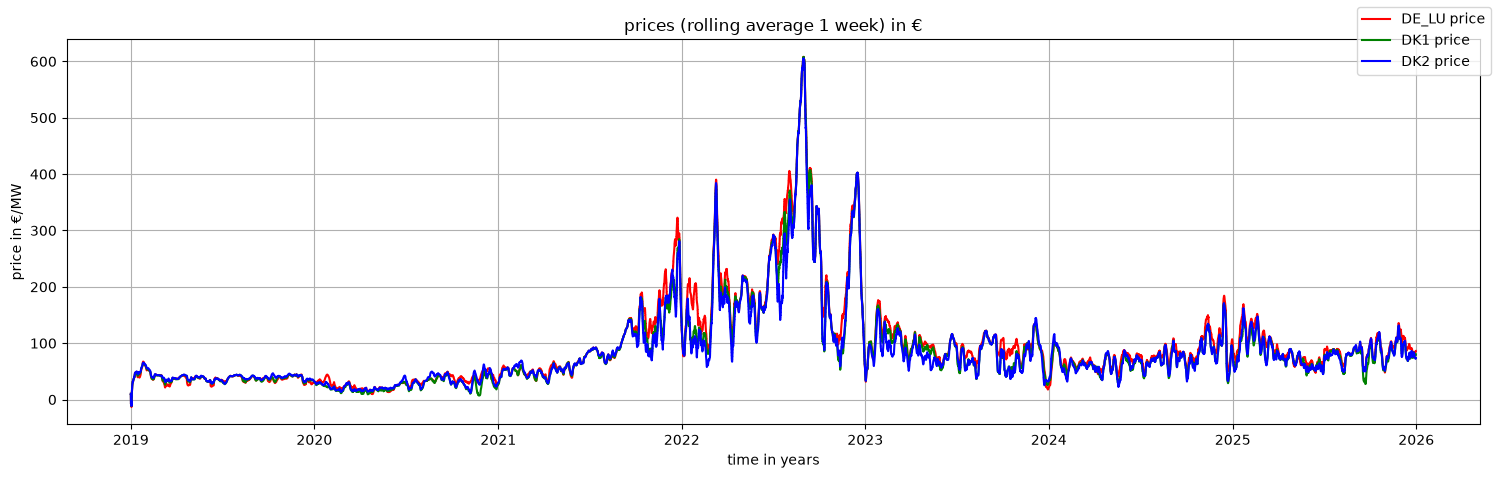

In [26]:
q = (
    lf_energy.rolling('time', period='1w').agg(
        pl.col('DE_LU_price').mean().alias('DE_LU_price_ra'),
        pl.col('DK1_price').mean().alias('DK1_price_ra'),
        pl.col('DK2_price').mean().alias('DK2_price_ra'),
    )
).collect()

fig, ax = plt.subplots()
ax.step(
    x=q['time'],
    y=q['DE_LU_price_ra'],
    label='DE_LU price',
    color='red'
)
ax.step(
    x=q['time'],
    y=q['DK1_price_ra'],
    label='DK1 price',
    color='green',
)
ax.step(
    x=q['time'],
    y=q['DK2_price_ra'],
    label='DK2 price',
    color='blue',
)
ax.grid()
ax.set_title('prices (rolling average 1 week) in €')
ax.set_xlabel('time in years')
ax.set_ylabel('price in €/MW')
fig.set_figwidth(15)
fig.legend()
fig.tight_layout()
plt.show()

As we can see there is a very large spike between mid 2021 to 2023. With the prices being quite "calm" before and more volatile and slightly elevated ever after. This corresponds to the 2021-2023 energy crisis brought about mainly by the russian invasion of ukraine and the recovery of the stress put on the economy through the COVID-19 Pandemic.

Although the prices in the different zones largely follow the same patterns, they do still differ in some cases.

In [27]:
cols = ['DE_LU_price', 'DK1_price', 'DK2_price']
prices = pl.concat_list(cols)
sd = lf_energy.select(
    sd = pl.concat_list(pl.col(cols)).list.std().max(),
).collect().item()
print(f'standard deviation of the three bidding zones: {sd:.5f}')

standard deviation of the three bidding zones: 271.49905


There are also weekly and daily patterns.

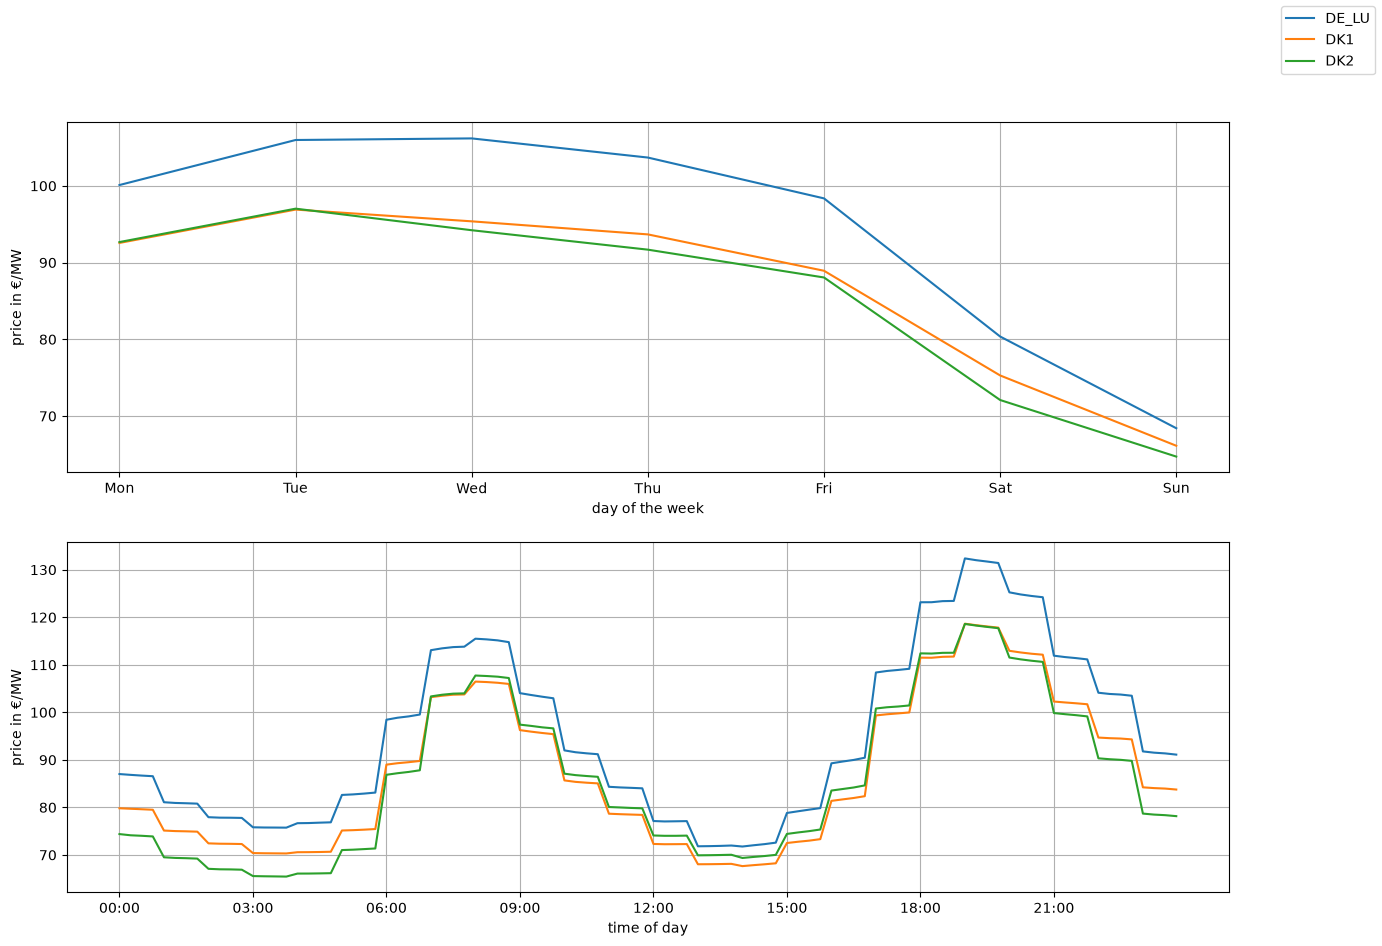

In [41]:
cols = ['DE_LU_price', 'DK1_price', 'DK2_price']

week = (
    lf_energy.with_columns(weekday = pl.col('time').dt.weekday())
      .group_by('weekday')
      .agg(pl.col(cols).mean())
      .sort('weekday')
)
names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
week = week.with_columns(pl.col('weekday').map_elements(lambda d: names[d - 1], return_dtype=pl.String).alias('day')).collect()

day = (
    lf_energy.with_columns(time = pl.col('time').dt.time())
      .group_by('time')
      .agg(pl.col(cols).mean())
      .sort('time')
).collect()


colors = ['C0', 'C1', 'C2']
fig, axs = plt.subplots(2)
fig.set_figwidth(15)
fig.set_figheight(10)
axs[0].plot(
    week['day'],
    week['DE_LU_price'],
    color=colors[0],
)
axs[0].plot(
    week['day'],
    week['DK1_price'],
    color=colors[1],
)
axs[0].plot(
    week['day'],
    week['DK2_price'],
    color=colors[2],
)
axs[0].grid()
axs[0].set_ylabel('price in €/MW')
axs[0].set_xlabel('day of the week')

t = (day['time'].dt.hour() + day['time'].dt.minute() / 60).to_numpy()   # if it's still a datetime column

axs[1].plot(
    t,
    day['DE_LU_price'],
    color=colors[0],
    label='DE_LU'
)
axs[1].plot(
    t,
    day['DK1_price'],
    color=colors[1],
    label='DK1'
)
axs[1].plot(
    t,
    day['DK2_price'],
    color=colors[2],
    label='DK2'
)
axs[1].set_ylabel('price in €/MW')
axs[1].set_xlabel('time of day')
axs[1].grid()
axs[1].set_xticks(range(0, 24, 3), [f'{h:02d}:00' for h in range(0, 24, 3)])
fig.legend()
plt.show()

## Load
The load of the three regions has roughly the same shape but is scaled to different values.

standard deviation of the three bidding zones: 45912.10071


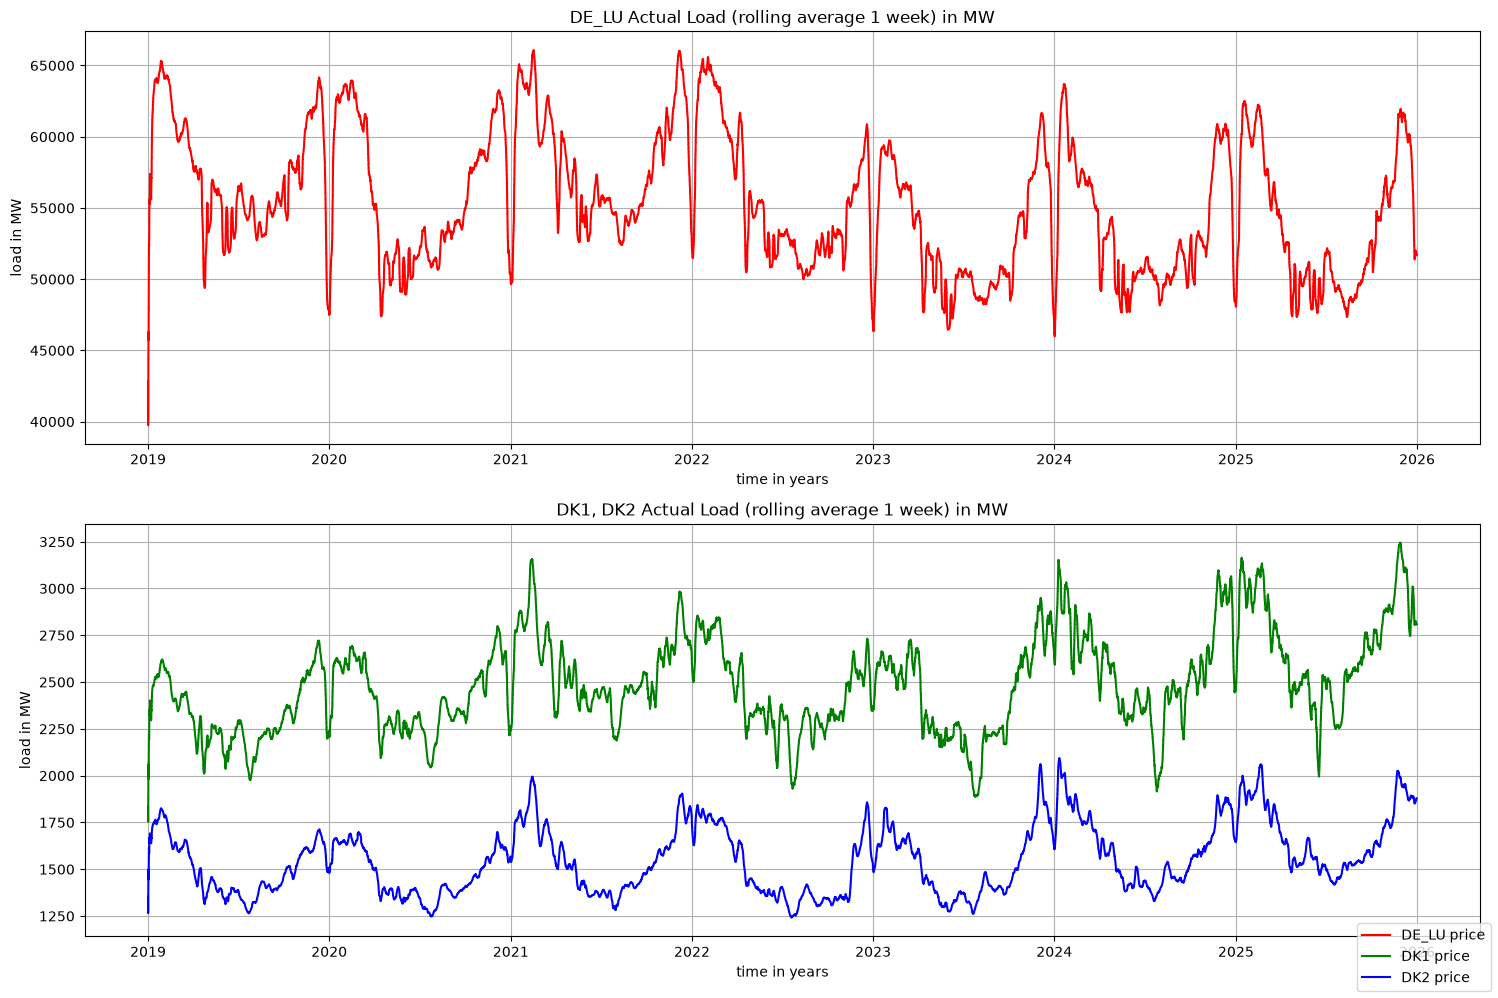

In [43]:
cols = ['DE_LU_Actual Load', 'DK1_Actual Load', 'DK2_Actual Load']
prices = pl.concat_list(cols)
sd = lf_energy.select(
    sd = pl.concat_list(pl.col(cols)).list.std().max(),
).collect().item()
print(f'standard deviation of the three bidding zones: {sd:.5f}')

q = (
    lf_energy.rolling('time', period='1w').agg(
        pl.col('DE_LU_Actual Load').mean().alias('DE_LU_load_ra'),
        pl.col('DK1_Actual Load').mean().alias('DK1_load_ra'),
        pl.col('DK2_Actual Load').mean().alias('DK2_load_ra'),
    ).collect()
)

fig, axs = plt.subplots(2)
axs[0].step(
    x=q['time'],
    y=q['DE_LU_load_ra'],
    label='DE_LU price',
    color='red'
)
dk1 = axs[1].step(
    x=q['time'],
    y=q['DK1_load_ra'],
    label='DK1 price',
    color='green',
)
dk2 = axs[1].step(
    x=q['time'],
    y=q['DK2_load_ra'],
    label='DK2 price',
    color='blue',
)
axs[0].grid()
axs[0].set_xlabel('time in years')
axs[0].set_ylabel('load in MW')
axs[1].grid()
axs[1].set_xlabel('time in years')
axs[1].set_ylabel('load in MW')
axs[0].set_title('DE_LU Actual Load (rolling average 1 week) in MW')
axs[1].set_title('DK1, DK2 Actual Load (rolling average 1 week) in MW')
fig.legend(loc='lower right'),
fig.set_figwidth(15)
fig.set_figheight(10)
fig.tight_layout()
plt.show()

It is also of note, that there is a very strong yearly pattern. Here shown with the german load data.

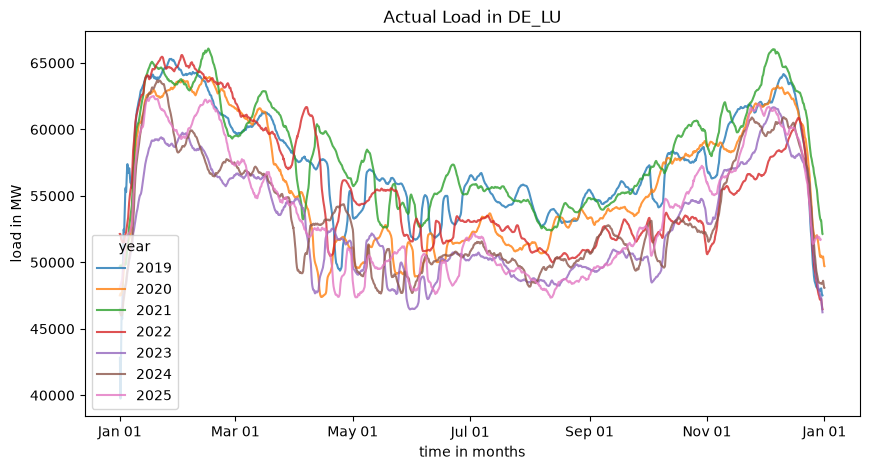

In [44]:
t = pl.col('time').dt.replace_time_zone(None)


q = (lf_energy.rolling('time', period='1w')
     .agg(pl.col('DE_LU_Actual Load').mean().alias('DE_LU_load_ra'))
     .with_columns(
        year = pl.col('time').dt.year(),
        x = pl.datetime(2000, 1, 1) + (t - t.dt.truncate('1y')),
     )
).collect()

fig, ax = plt.subplots(figsize=(10, 5))
for (year,), g in q.partition_by('year', as_dict=True, maintain_order=True).items():
    ax.plot(g['x'], g['DE_LU_load_ra'], label=str(year), alpha=0.8)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(title='year')
ax.set_xlabel('time in months')
ax.set_ylabel('load in MW')
ax.set_title('Actual Load in DE_LU')
plt.show()

At this point we can also notice that when the prices spiked during the energy crisis the demand for electricity did not change in any considerable way. It can be considered inelastic.

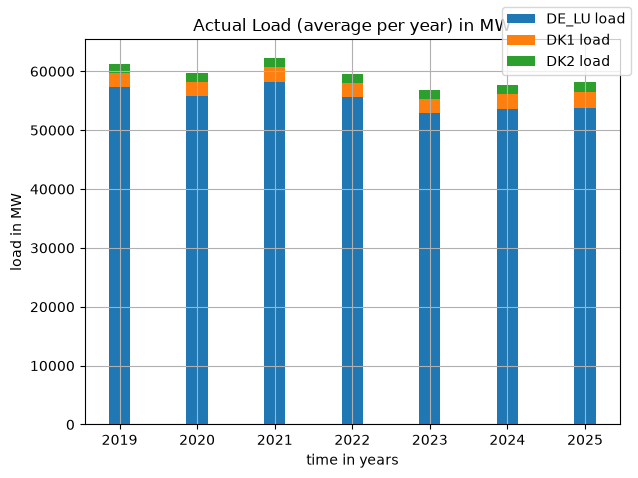

In [45]:
q = (
    lf_energy.group_by_dynamic('time', period='1y', every='1y').agg(
        pl.col('DE_LU_Actual Load').mean().alias('DE_LU_load_ra'),
        pl.col('DK1_Actual Load').mean().alias('DK1_load_ra'),
        pl.col('DK2_Actual Load').mean().alias('DK2_load_ra'),
    ).collect()
)


bottom = pl.zeros(7, eager=True)
fig, ax = plt.subplots()
ax.bar(
    x=q['time'],
    height=q['DE_LU_load_ra'],
    bottom=bottom,
    label='DE_LU load',
    width=100,
)
bottom += q['DE_LU_load_ra']
ax.bar(
    x=q['time'],
    height=q['DK1_load_ra'],
    bottom=bottom,
    label='DK1 load',
    width=100,
)
bottom += q['DK1_load_ra']
ax.bar(
    x=q['time'],
    height=q['DK2_load_ra'],
    bottom=bottom,
    label='DK2 load',
    width=100,
)
ax.grid()
ax.set_xlabel('time in years')
ax.set_ylabel('load in MW')
ax.set_title('Actual Load (average per year) in MW')
fig.tight_layout()
fig.legend()
plt.show()

There again are also weekly and monthly patterns.

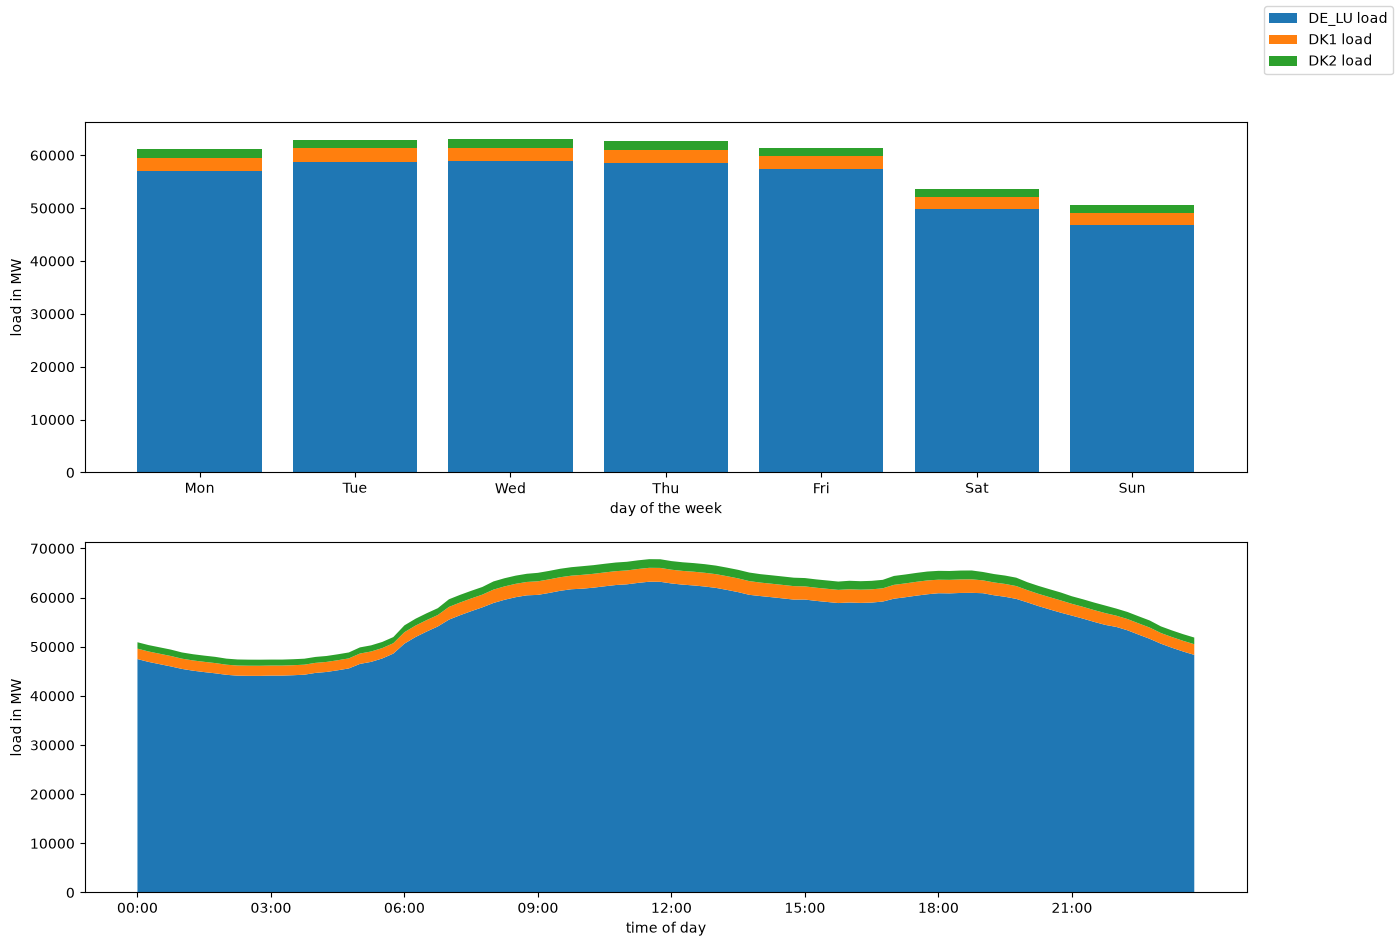

In [47]:
week = (
    lf_energy.with_columns(weekday = pl.col('time').dt.weekday())
      .group_by('weekday')
      .agg(pl.col(cols).mean())
      .sort('weekday')
)
names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
week = week.with_columns(pl.col('weekday').map_elements(lambda d: names[d - 1], return_dtype=pl.String).alias('day')).collect()

day = (
    lf_energy.with_columns(time = pl.col('time').dt.time())
      .group_by('time')
      .agg(pl.col(cols).mean())
      .sort('time')
).collect()


colors = ['C0', 'C1', 'C2']
bottom = pl.zeros(7, eager=True)
fig, axs = plt.subplots(2)
fig.set_figwidth(15)
fig.set_figheight(10)
axs[0].bar(
    x=week['day'],
    height=week['DE_LU_Actual Load'],
    bottom=bottom,
    color=colors[0],
)
bottom += week['DE_LU_Actual Load']
axs[0].bar(
    x=week['day'],
    height=week['DK1_Actual Load'],
    bottom=bottom,
    color=colors[1],
)
bottom += week['DK1_Actual Load']
axs[0].bar(
    x=week['day'],
    height=week['DK2_Actual Load'],
    bottom=bottom,
    color=colors[2],
)
axs[0].set_xlabel('day of the week')
axs[0].set_ylabel('load in MW')

t = (day['time'].dt.hour() + day['time'].dt.minute() / 60).to_numpy()   # if it's still a datetime column

axs[1].stackplot(
    t,
    day['DE_LU_Actual Load'].to_numpy(),
    day['DK1_Actual Load'].to_numpy(),
    day['DK2_Actual Load'].to_numpy(),
    labels=['DE_LU load', 'DK1 load', 'DK2 load'],
)
axs[1].set_xticks(range(0, 24, 3), [f'{h:02d}:00' for h in range(0, 24, 3)])
axs[1].set_xlabel('time of day')
axs[1].set_ylabel('load in MW')
fig.legend()
plt.show()

## Generation Mix
For the generation mix there is an actual difference between the different zones. Let us take a look at the aggregated production mix over the whole period in each of the regions as well as the combined mix of all three. As we can see combined mix of them is very close to the mix of germany as it is has the biggest values by far.

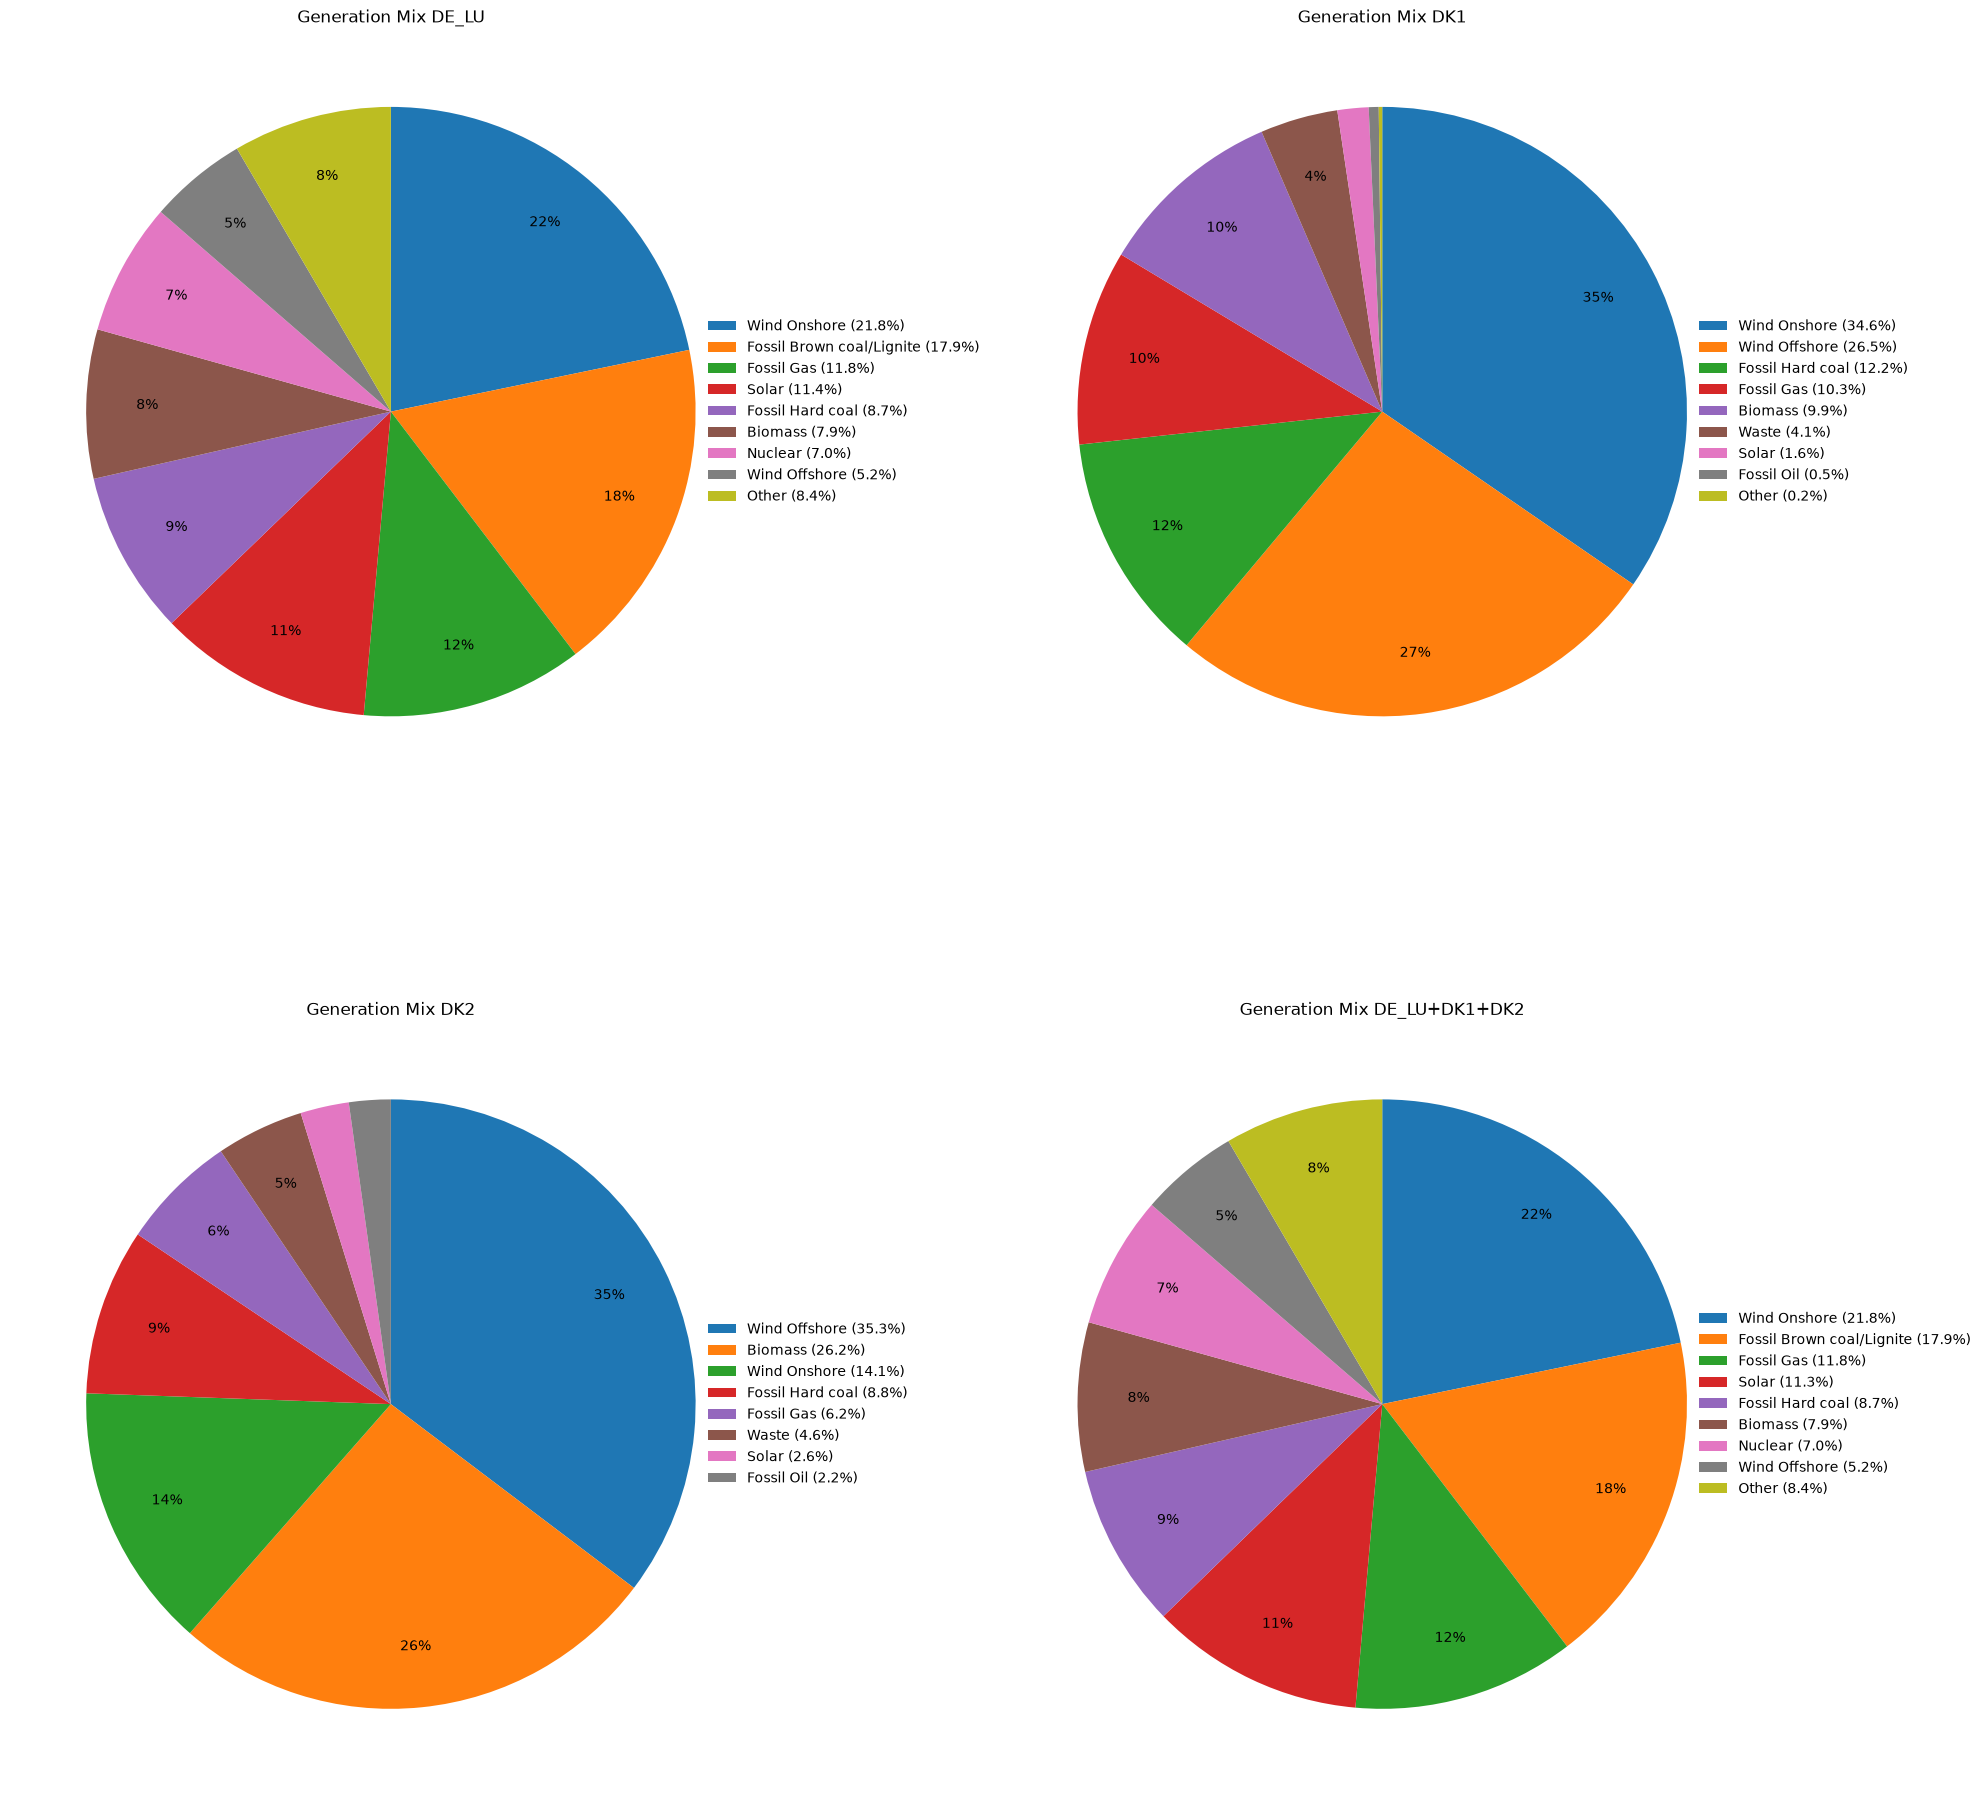

In [33]:
def visualize_mix(df: pl.DataFrame, ax: plt.Axes) -> None:

    data = sorted(zip(df.columns, df.row(0)), key=lambda kv: kv[1], reverse=True)

    N = 8
    top, rest = data[:N], data[N:]
    if rest:
        top.append(('Other', sum(v for _, v in rest)))

    labels, values = zip(*top)
    total = sum(values)

    wedges, _, autotexts = ax.pie(
        values,
        autopct=lambda p: f'{p:.0f}%' if p >= 4 else '',
        startangle=90,
        counterclock=False,
        pctdistance=0.8,
    )

    ax.legend(
        wedges,
        [f'{l} ({v / total:.1%})' for l, v in top],
        loc='center left',
        bbox_to_anchor=(0.9, 0.5),
        frameon=False,
    )


lf = lf_energy.sum()

COUNTRIES = ['DE_LU', 'DK1', 'DK2']

dfs = []

for i, c in enumerate(COUNTRIES):
    df = lf.select(sc.starts_with(f'{c}_')) \
        .select(sc.ends_with('\'Actual Aggregated\')') \
               .exclude(f'{c}_price', f'{c}_Actual Load')).collect()
    df.columns = [col.removeprefix(f'{c}_(\'') \
                           .removesuffix('\', \'Actual Aggregated\')') for col in df.columns]

    dfs.append(df)

summed = pl.concat(dfs, how='diagonal').fill_null(0).sum()

fig, axs = plt.subplots(2,2)
fig.set_figwidth(20)
fig.set_figheight(20)
visualize_mix(dfs[0], axs[0][0])
visualize_mix(dfs[1], axs[0][1])
visualize_mix(dfs[2], axs[1][0])
visualize_mix(summed, axs[1][1])
axs[0][0].set_title('Generation Mix DE_LU')
axs[0][1].set_title('Generation Mix DK1')
axs[1][0].set_title('Generation Mix DK2')
axs[1][1].set_title('Generation Mix DE_LU+DK1+DK2')
fig.tight_layout()
plt.show()

## Density Distributions
Here we can see particularly well the phenomenon of negative energy prices!

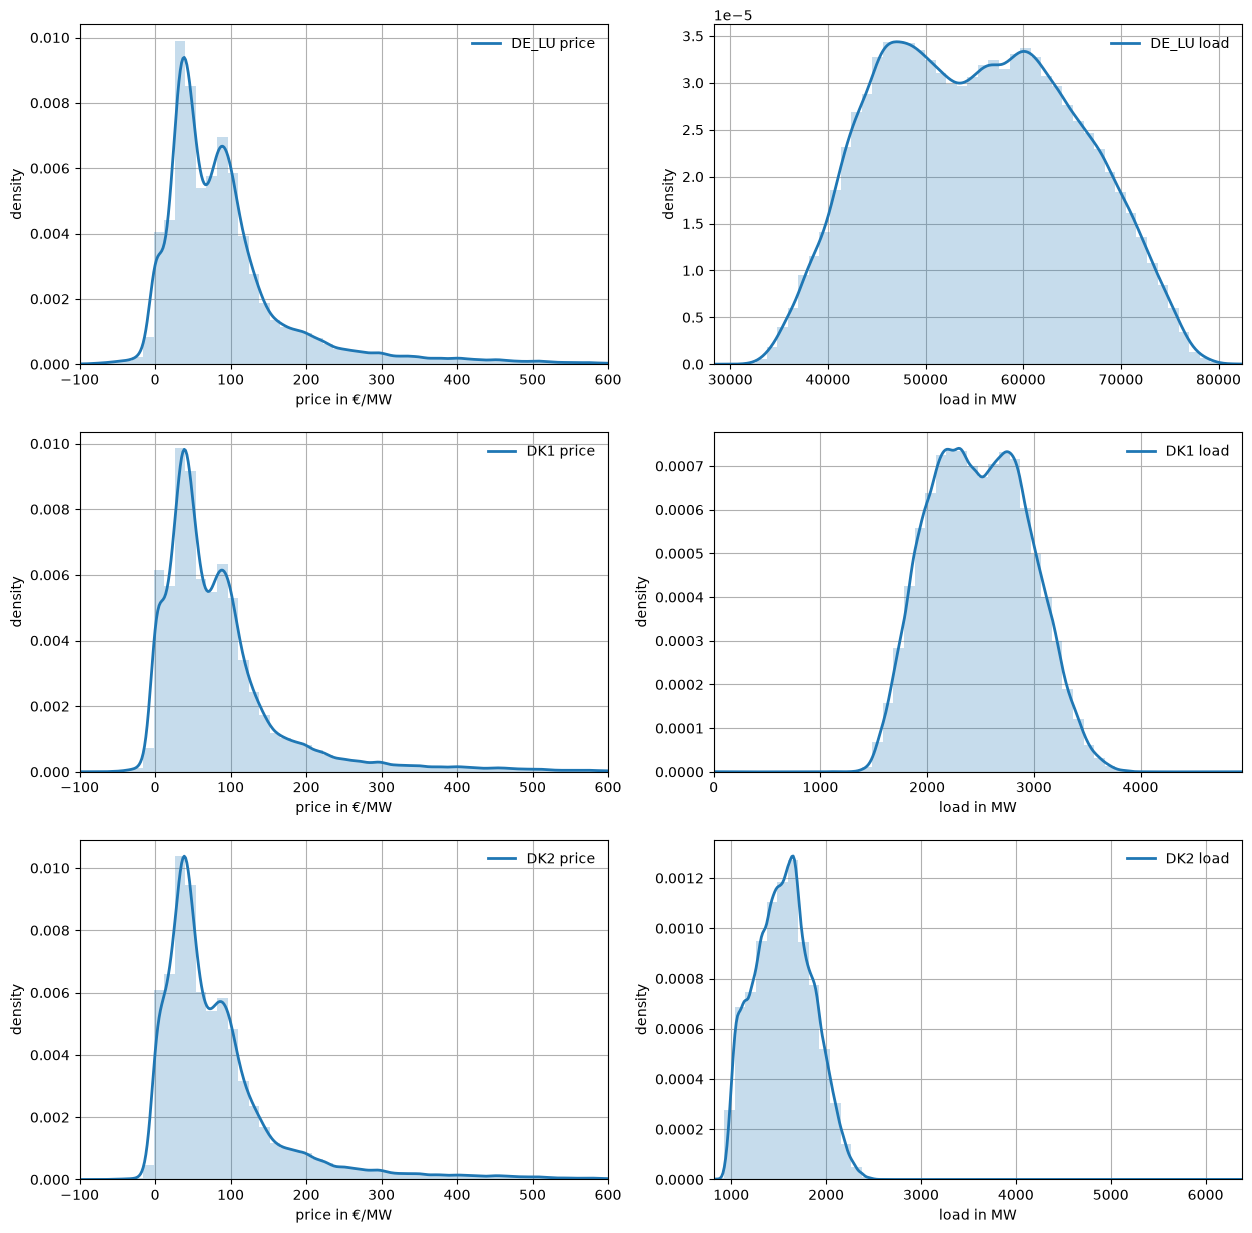

In [51]:
def hist_kde(series_dict, bins=50, bw=None, xlim=None, ax=None, colors=None):
    ax = ax or plt.subplots(figsize=(9, 4))[1]
    data = {k: v.drop_nulls().drop_nans().to_numpy() for k, v in series_dict.items()}

    lo = min(a.min() for a in data.values()) if xlim is None else xlim[0]
    hi = max(a.max() for a in data.values()) if xlim is None else xlim[1]
    edges = np.linspace(lo, hi, bins + 1)
    grid = np.linspace(lo, hi, 400)
    colors = colors or [f'C{i}' for i in range(len(data))]

    for (label, a), c in zip(data.items(), colors):
        ax.hist(a, bins=edges, density=True, color=c, alpha=0.25)
        ax.plot(grid, scipy.stats.gaussian_kde(a, bw_method=bw)(grid), color=c, lw=2, label=label)

    ax.set_xlim(lo, hi)
    ax.set_ylabel('density')
    ax.grid()
    ax.set_axisbelow(True)
    ax.legend(frameon=False)
    return ax


fig, axs = plt.subplots(3,2)
hist_kde({'DE_LU price': lf_energy.collect()['DE_LU_price']}, xlim=(-100, 600), ax=axs[0][0])
hist_kde({'DK1 price': lf_energy.collect()['DK1_price']}, xlim=(-100, 600), ax=axs[1][0])
hist_kde({'DK2 price': lf_energy.collect()['DK2_price']}, xlim=(-100, 600), ax=axs[2][0])

hist_kde({'DE_LU load': lf_energy.collect()['DE_LU_Actual Load']}, ax=axs[0][1])
hist_kde({'DK1 load': lf_energy.collect()['DK1_Actual Load']}, ax=axs[1][1])
hist_kde({'DK2 load': lf_energy.collect()['DK2_Actual Load']}, ax=axs[2][1])
fig.set_figheight(15)
fig.set_figwidth(15)

for a in axs:
    a[0].set_xlabel('price in €/MW')
    a[1].set_xlabel('load in MW')

plt.show()

We can also see what looks to be two centers of density and a heavy tail to the distribution.

## Autocorrelation
The following statistics inform us to which level past datapoints are correlated to current ones.
This will be important for a number of statistical models in the next notebook.

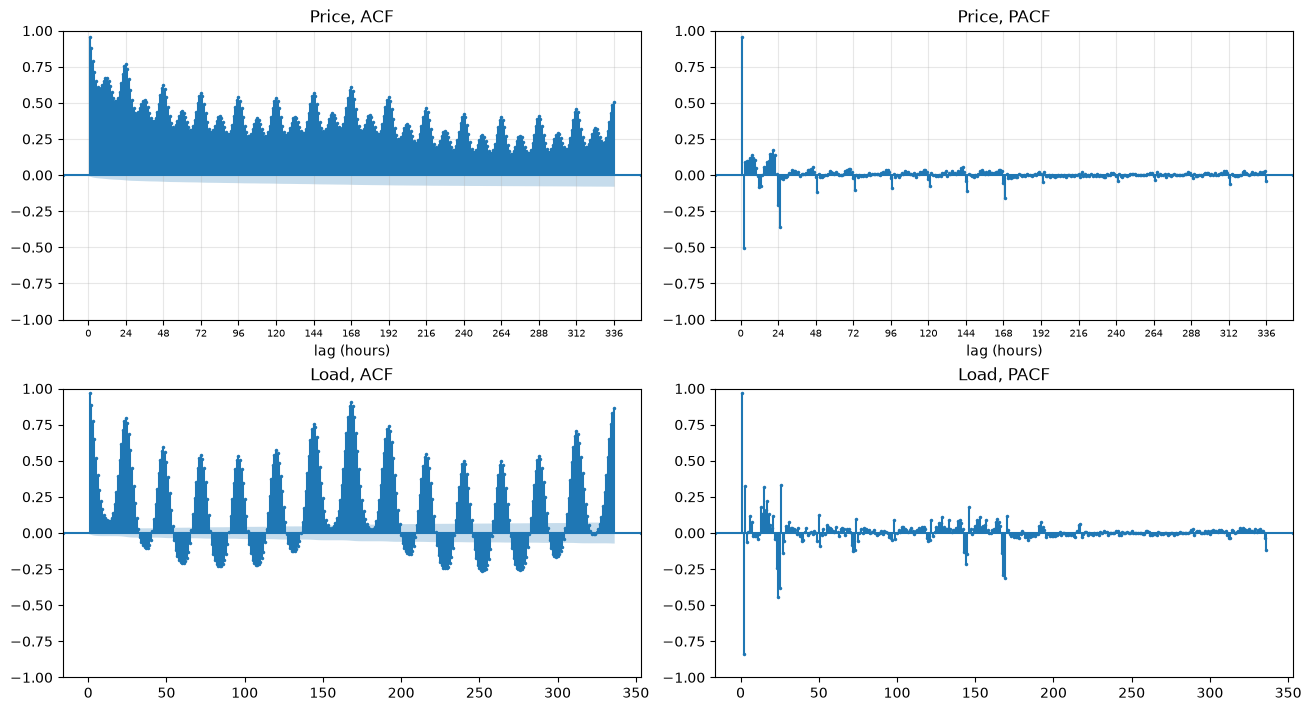

In [35]:
YEAR_H = 8766.0 # 365.25 days in hours
LAGS = 24 * 7 * 2 # two weeks of hourly lags

PRICE, LOAD, TIME = 'DE_LU_price', 'DE_LU_Actual Load', 'time'

hourly = lf_energy.select(pl.col(TIME), pl.col(PRICE)).group_by_dynamic('time', every='1h').agg(pl.col(PRICE).mean()).drop_nulls().collect()

# detrend
y = hourly[PRICE].to_numpy()
y = y - scipy.ndimage.uniform_filter1d(y, size=int(YEAR_H), mode='nearest')

LAGS = 24 * 7 * 2 # two weeks of hourly lags
fig, axs = plt.subplots(2, 2, figsize=(13, 7), constrained_layout=True)

plot_acf(y, lags=LAGS, zero=False, ax=axs[0, 0], marker='.', markersize=3, title=f'Price, ACF')
plot_pacf(y, lags=LAGS, zero=False, ax=axs[0, 1], method='ywm', marker='.', markersize=3,
            title=f'Price, PACF')
for ax in axs[0]:
    ax.set_xlabel('lag (hours)')
    ax.set_xticks(range(0, LAGS + 1, 24))
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(alpha=0.3)


hourly = lf_energy.select(pl.col(TIME), pl.col(LOAD)).group_by_dynamic('time', every='1h').agg(pl.col(LOAD).mean()).drop_nulls().collect()

# detrend
y = hourly[LOAD].to_numpy()
y = y - scipy.ndimage.uniform_filter1d(y, size=int(YEAR_H), mode='nearest')

plot_acf(y, lags=LAGS, zero=False, ax=axs[1, 0], marker='.', markersize=3, title=f'Load, ACF')
plot_pacf(y, lags=LAGS, zero=False, ax=axs[1, 1], method='ywm', marker='.', markersize=3,
            title=f'Load, PACF')
for ax in axs[0]:
    ax.set_xlabel('lag (hours)')
    ax.set_xticks(range(0, LAGS + 1, 24))
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(alpha=0.3)

plt.show()

## Periodicity
Running fourier analysis on the load and price data we might be able to find more periodic aspects of the data apart from daily, weekly and yearly patterns.

DE_LU_Actual Load [MW]: step = 0.25 h, span = 7.0 years
shape: (5, 3)
┌────────┬──────────┬─────────────┐
│ cycle  ┆ period_h ┆ amplitude   │
│ ---    ┆ ---      ┆ ---         │
│ str    ┆ f64      ┆ f64         │
╞════════╪══════════╪═════════════╡
│ 8 h    ┆ 8.0      ┆ 452.703893  │
│ 12 h   ┆ 12.0     ┆ 3566.814133 │
│ 24 h   ┆ 24.0     ┆ 8499.697931 │
│ 1 week ┆ 168.0    ┆ 5536.619419 │
│ 1 year ┆ 8766.0   ┆ 4509.250184 │
└────────┴──────────┴─────────────┘
DE_LU_price [EUR/MWh]: step = 0.25 h, span = 7.0 years
shape: (5, 3)
┌────────┬──────────┬───────────┐
│ cycle  ┆ period_h ┆ amplitude │
│ ---    ┆ ---      ┆ ---       │
│ str    ┆ f64      ┆ f64       │
╞════════╪══════════╪═══════════╡
│ 8 h    ┆ 8.0      ┆ 5.565861  │
│ 12 h   ┆ 12.0     ┆ 27.599896 │
│ 24 h   ┆ 24.0     ┆ 15.163486 │
│ 1 week ┆ 168.0    ┆ 22.752132 │
│ 1 year ┆ 8766.0   ┆ 28.636855 │
└────────┴──────────┴───────────┘


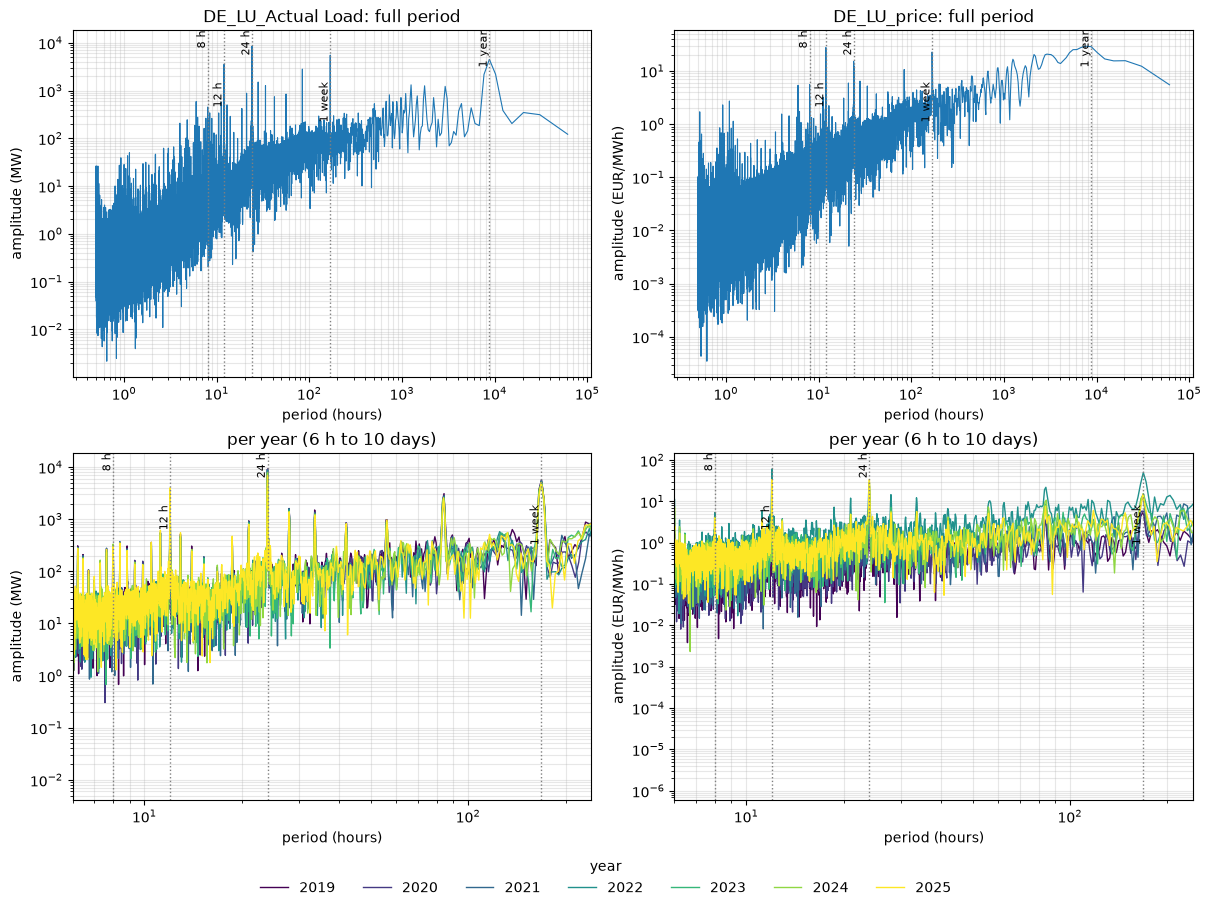

In [36]:
LOAD, PRICE, TIME = 'DE_LU_Actual Load', 'DE_LU_price', 'time'
SERIES = {LOAD: 'MW', PRICE: 'EUR/MWh'}                    # column -> unit
YEAR_H = 8766.0                                            # 365.25 days in hours
CYCLES = {'8 h': 8.0, '12 h': 12.0, '24 h': 24.0, '1 week': 168.0, '1 year': YEAR_H}


def regular_series(df, col, time_col=TIME):
    df = (df.select(time_col, col).sort(time_col)
            .with_columns(pl.col(time_col).dt.convert_time_zone('UTC')))
    step = df[time_col].diff().drop_nulls().mode().min()
    out = (df.upsample(time_col, every=f'{int(step.total_seconds())}s')
             .with_columns(pl.col(col).interpolate()
                           .fill_null(strategy='forward').fill_null(strategy='backward')))
    return out, step.total_seconds() / 3600


def spectrum(y, step_h, detrend_days):
    y = y - scipy.ndimage.uniform_filter1d(y, size=int(detrend_days * 24 / step_h), mode='nearest')
    w = np.hanning(len(y))
    X = np.fft.rfft(y * w)
    freq = np.fft.rfftfreq(len(y), d=step_h)
    return freq[1:], 2 * np.abs(X[1:]) / w.sum()


def amp_at(freq, amp, period_h, tol=0.02):
    m = np.abs(1 / freq / period_h - 1) < tol
    return float(amp[m].max()) if m.any() else float('nan')


def guides(ax):
    lo, hi = ax.get_xlim()
    for i, (label, p) in enumerate(CYCLES.items()):
        if lo <= p <= hi:                                  # skip cycles outside the visible range
            ax.axvline(p, color='grey', ls=':', lw=1)
            ax.text(p, 1.0 - 0.15 * (i % 2), label, transform=ax.get_xaxis_transform(),
                    rotation=90, va='top', ha='right', fontsize=8, clip_on=True)


df_energy = lf_energy.collect()                               # collect once
fig, axs = plt.subplots(2, len(SERIES), figsize=(12, 9), constrained_layout=True, squeeze=False)

for j, (col, unit) in enumerate(SERIES.items()):
    ts, step_h = regular_series(df_energy, col)

    # full-period spectrum
    freq, amp = spectrum(ts[col].to_numpy(), step_h, detrend_days=365.25)
    print(f'{col} [{unit}]: step = {step_h} h, span = {ts.height * step_h / YEAR_H:.1f} years')
    print(pl.DataFrame({
        'cycle': list(CYCLES),
        'period_h': list(CYCLES.values()),
        'amplitude': [amp_at(freq, amp, p) for p in CYCLES.values()],
    }))

    ax = axs[0, j]
    ax.loglog(1 / freq, amp, lw=0.8)
    guides(ax)
    ax.set_title(f'{col}: full period')
    ax.set_xlabel('period (hours)')
    ax.set_ylabel(f'amplitude ({unit})')
    ax.grid(alpha=0.3, which='both')

    # per-year spectra, 6 h to 10 days
    ax = axs[1, j]
    years = ts[TIME].dt.year().unique().sort().to_list()
    for i, yr in enumerate(years):
        yy = ts.filter(pl.col(TIME).dt.year() == yr)[col].to_numpy()
        f, a = spectrum(yy, step_h, detrend_days=30)
        ax.loglog(1 / f, a, lw=1, color=plt.cm.viridis(i / max(len(years) - 1, 1)), label=str(yr))
    ax.set_xlim(6, 240)
    guides(ax)
    ax.set_title('per year (6 h to 10 days)')
    ax.set_xlabel('period (hours)')
    ax.set_ylabel(f'amplitude ({unit})')
    ax.grid(alpha=0.3, which='both')

handles, labels = axs[1, 0].get_legend_handles_labels()    # same year colors in every column
fig.legend(handles, labels, loc='outside lower center', ncol=len(labels), title='year', frameon=False)
plt.show()

_note: this codeblock was written using Claude Sonnet 5._

As expected the biggest periodicties are weekly, daily and yearly.

## Correlation between data
Finally we will explore in what ways the different datasets correlate with each other.
This will be important in choosing which inputs might be important to predict which outputs.

It is important that we remove as many known patterns from the data as possible since common patterns in the different sets of data will artificially increase the correlation.

We also test for a lagged correlation between the german load and price to account for reaction time of one to teh other.

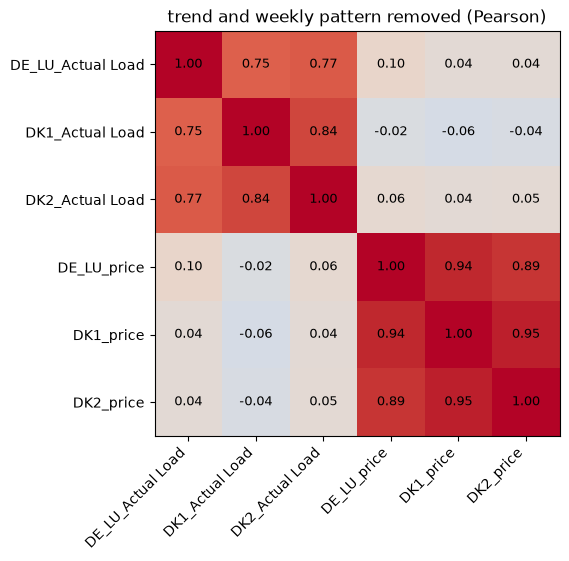

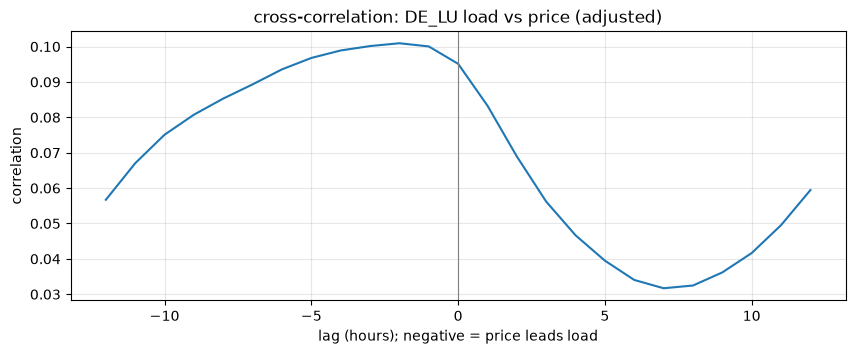

In [37]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

COLS = ["DE_LU_Actual Load", "DK1_Actual Load", "DK2_Actual Load", "DE_LU_price", "DK1_price", "DK2_price"]
TIME, YEAR_H = "time", 8766.0

hourly = (
    df_energy.select(TIME, *COLS)
        .with_columns(pl.col(TIME).dt.convert_time_zone("UTC"))
        .sort(TIME)
        .group_by_dynamic(TIME, every="1h").agg(pl.col(COLS).mean())
        .drop_nulls()
)


def adjust(frame, cols):
    how = ((frame[TIME].dt.weekday().cast(pl.Int32) - 1) * 24
           + frame[TIME].dt.hour().cast(pl.Int32)).alias("how")
    out = {}
    for c in cols:
        y = frame[c].to_numpy()
        y = y - uniform_filter1d(y, size=int(YEAR_H), mode="nearest")
        out[c] = (pl.DataFrame({"how": how, "y": y})
                    .with_columns(pl.col("y") - pl.col("y").mean().over("how"))["y"])
    return pl.DataFrame(out)


def corr_heatmap(ax, frame, title, method="pearson"):
    f = frame.select(pl.all().rank()) if method == "spearman" else frame
    C = f.corr().to_numpy()
    im = ax.imshow(C, cmap="coolwarm", vmin=-1, vmax=1) 
    ax.set_xticks(range(len(COLS)), COLS, rotation=45, ha="right")
    ax.set_yticks(range(len(COLS)), COLS)
    for i in range(len(COLS)):
        for j in range(len(COLS)):
            ax.text(j, i, f"{C[i, j]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(title)
    return im


adj = adjust(hourly, COLS)


fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
im = corr_heatmap(ax, adj, "trend and weekly pattern removed (Pearson)")
fig.colorbar(im, ax=axs, shrink=0.8, label="correlation")
plt.show()


def xcorr(x, y, max_lag):
    x = (x - x.mean()) / x.std()
    y = (y - y.mean()) / y.std()
    lags = np.arange(-max_lag, max_lag + 1)
    r = [np.mean(x[:len(x) - k] * y[k:]) if k >= 0 else np.mean(x[-k:] * y[:len(y) + k]) for k in lags]
    return lags, np.array(r)

lags, r = xcorr(adj["DE_LU_Actual Load"].to_numpy(), adj["DE_LU_price"].to_numpy(), max_lag=12)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(lags, r, lw=1.5)
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("lag (hours); negative = price leads load")
ax.set_ylabel("correlation")
ax.set_title("cross-correlation: DE_LU load vs price (adjusted)")
ax.grid(alpha=0.3)
plt.show()

As we had discovered before the prices of the three zones are very closely related. As is the load although not as much as the price.

The Correlation of price and load is far less strong. The load DE_LU and DK2 have a slight positive corelation to price of all zones with the impact of the DE_LU load on the DE_LU price being the strongest. As we see in the plot of the lagged cross-correlation the price slightly anticipates increased load.

## Correlation of Generation Mix

Due to the Merit-Order-Effect the correlation of certain kinds of generation methods should have an effect on the price as well.
So here is the correlation heatmap of all data of our dataset from ENTSO-E.

In [54]:
COLS = lf_energy.collect_schema().names()
COLS.remove('time')
COLS = list(filter(lambda x: not 'Consumption' in x, COLS))

hv.extension("bokeh")


def corr_heatmap(frame: pl.DataFrame, method="pearson", cluster=True, triangle=True, title=None):
    frame = frame.drop_nulls()
    if method == "spearman":
        frame = frame.select(pl.all().rank())          # rank correlation, robust to price spikes
    cols, n = frame.columns, frame.width

    C = np.nan_to_num(np.corrcoef(frame.to_numpy(), rowvar=False))   # constant columns give NaN
    np.fill_diagonal(C, 1.0)

    order = np.arange(n)
    if cluster and n > 2:                              # group similar variables into blocks
        D = 1 - np.abs(C)
        np.fill_diagonal(D, 0)
        order = leaves_list(linkage(squareform((D + D.T) / 2, checks=False), "average", optimal_ordering=True))

    names = [cols[k] for k in order]
    Co = C[np.ix_(order, order)]
    i, j = np.triu_indices(n) if triangle else np.indices((n, n)).reshape(2, -1)
    long = pl.DataFrame({"x": [names[k] for k in j], "y": [names[k] for k in i], "corr": Co[i, j]})

    size = int(min(900, max(350, 11 * n)))

    plot = long.hvplot.heatmap(
        x="x", y="y", C="corr",
        cmap="RdBu_r", clim=(-1, 1), colorbar=True,    # fixed scale: white is always zero
        frame_width=size, frame_height=size,
        xaxis=None, yaxis=None,
        fontsize={"xticks": 6, "yticks": 6},
        xlabel="", ylabel="",
        tools=["hover"], toolbar="above",
        title=title or f"{method} correlation",
    ).redim.values(x=names, y=names)                   # keep the clustered order (default is alphabetical)
    return plot, names


hourly = (
    df_energy.select(TIME, *COLS)
        .with_columns(pl.col(TIME).dt.convert_time_zone("UTC"))
        .sort(TIME)
        .group_by_dynamic(TIME, every="1h").agg(pl.col(COLS).mean())
        .drop_nulls()
)

adj = adjust(hourly, COLS)


plot, order = corr_heatmap(adj)
plot

:HeatMap   [x,y]   (corr)

_note: This codblock was created using Claude Sonnet 5_

There is a lot of very interesting things to learn from this graph. for example solar, wind and water energy being negatively correlated with the price.
This is a direct result of the Merit-Order-Effect. Similarly there is a strong positive correlation of price and most other generation methods.
Namely those, which are more flexible in how much energy they produce like fossil fuels have a strong positive correlation with price.
This might have two reasons. Either they are being used to cover predictable spikes in load during which price will rise as well.
In this case they would rise at the same time but not necessarily be the cause for each other rising. 
The other explanation would be that if the renewable energy sources aren't putting out as much i.e. a rainy cloudy day without much wind
the more expensive fossil fueled energy would have to cover the difference.
Renewable energy sources are also negatively correlated with most other energy sources which is a sign for the second explanation being
true at least in some cases. 

Off- and Onshore wind is also positively correlated. Besides that there is little correlation between renewable energy sources. Most other sources are positively correlated with each other and the load.

------

Corresponding data from the different zones are positively correlated and in such the effects mentioned above also exist between cross-country data.

## Weather Data and Generation

In [56]:
lf_weather = (
    pl.scan_parquet(WEATHER_PARQUET_PATH)
    .with_columns(
        pl.col('time')
        .dt.cast_time_unit('us')
        .dt.replace_time_zone('UTC')
        .dt.convert_time_zone('Europe/Berlin')
    )
)


lf_weather_and_generation = (
    lf_energy.join(lf_weather, how='right', on='time')
)

COLS = (
    list(filter(
        lambda x: (('Actual Aggregated' in x) or ('Actual Load' in x) or 'germany' in x or 'luxembourg' in x or 'denmark' in x),
        lf_weather_and_generation.collect_schema().names(),
    ))
)



hourly = (
    lf_weather_and_generation.select(TIME, *COLS)
        .with_columns(pl.col(TIME).dt.convert_time_zone("UTC"))
        .sort(TIME)
        .group_by_dynamic(TIME, every="1h").agg(pl.col(COLS).mean())
        .drop_nulls()
).collect()

adj = adjust(hourly, COLS)

plot, order = corr_heatmap(adj)
plot

:HeatMap   [x,y]   (corr)

As expected the wind speeds are correlated to wind energy output, the solar radiation is positively correlated to the output of solar units and the temperature is negatively correlated to the actual load because heating is less of a concern. Also the wind speed at 100 meters height is slightly stronger correlated making it a better candidate as our input for the models.

## Conclusion
We have gotten a good overview of our data and were able to confirm many theories about which data is connected and what data is important.

**Prices**

The prices of the three zones we are looking at match each other closely, although not perfectly.
Therefore our models are likely going to largely translate between the zones and only require minor additional tweaking.
The 2021-2023 energy crisis however is likely going to be challenge. The data looks to be fundamentally different after it (more volatile and slightly elevated). 
Getting our model to accurately navigate this change will be challenging. 

The distributions themselves don't follow a gaussian shape, which we will have to keep in mind for our error assumption.

**Load**

Load seems largely inelastic. It was not affected by the energy crisis and follows the same shape in all regions. Its biggest driving forces are calendar and temperature effects.

**Periodicity and autocorrelation**

We only found the expected daily, weekly and yearly cycles in both load and price. Past values definitely carry information about future values
which suggests using autoregressive and seasonal models. For the machine learning models it suggests itself to encode the date information in a way
that uses this domain knowledge.

**Correlations**

The link between load and price is not as strong as expected once the seasonal profiles are removed. For the DE_LU zone we were able to find the strongest correlation.
It appears the price anticipates increased loads by 1-2 hours.

The strongest factors correlating with are the generation mix. Cheap energy sources push down the price, more expensive ones raise it.
Cross-country inputs might also be useful. Although it is not clear wether they just act as a stand-in for the corresponding value for the country of the target value
or wether they actually carry additional information. 

Is the price cheaper because if there is wind in Denmark, there is also wind in germany or is it the price cheaper because the danish wind energy pushes down the price of
the entire market?

**Weather**

Wind and solar radiation are closely related to wind and solar power generation and temperature negatively correlated with the load.

_note: The weather data we are using would not be available at the point at which the day-ahead prices are decided. However if we are able to accurately predict the price using the actual weather of the coming day then the problem of accurate price prediction has been reduced to accurate weather prediction._


**Implications for modelling**
1. Use calendar features (hour, weekday, holiday) and/or seasonal terms for the daily, weekly and yearly cycles.
2. Include load, renewable generation (or weather as a proxy for it) and neighbouring-zone prices as features.
3. Expect the crisis period to hurt a simple model. Evaluate it separately and consider a robust loss.
4. Start with simple autoregressive/seasonal baselines and compare them with tree-based or neural models that can use the additional features.
